In [1]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import userdata
import os

token = userdata.get('GITHUB_TOKEN')
username = "Manoj-R27"
email = "pes2ug23cs328@pesu.pes.edu"
repo = "recsys-causal-rl"

# Configure git
!git config --global user.email "{email}"
!git config --global user.name "{username}"

# Clone repo first
os.chdir('/content')
!git clone https://{token}@github.com/{username}/{repo}.git
print("Repo cloned!")

Cloning into 'recsys-causal-rl'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 21 (delta 4), reused 17 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 78.71 KiB | 5.62 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Repo cloned!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# Download and load MovieLens
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q ml-100k.zip

# Load data
ratings = pd.read_csv('ml-100k/u.data', sep='\t',
                      names=['user_id','movie_id','rating','timestamp'])
movies = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                     usecols=[0,1], names=['movie_id','title'])

# Rebuild Stage 1 model
user_movie_matrix = ratings.pivot_table(
    index='user_id', columns='movie_id', values='rating').fillna(0)

svd = TruncatedSVD(n_components=200, random_state=42)
matrix_svd = svd.fit_transform(user_movie_matrix)

user_similarity_df = pd.DataFrame(
    cosine_similarity(matrix_svd),
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index)

print("Stage 1 model loaded!")
print(f"Users: {ratings['user_id'].nunique()}, Movies: {ratings['movie_id'].nunique()}")

Stage 1 model loaded!
Users: 943, Movies: 1682


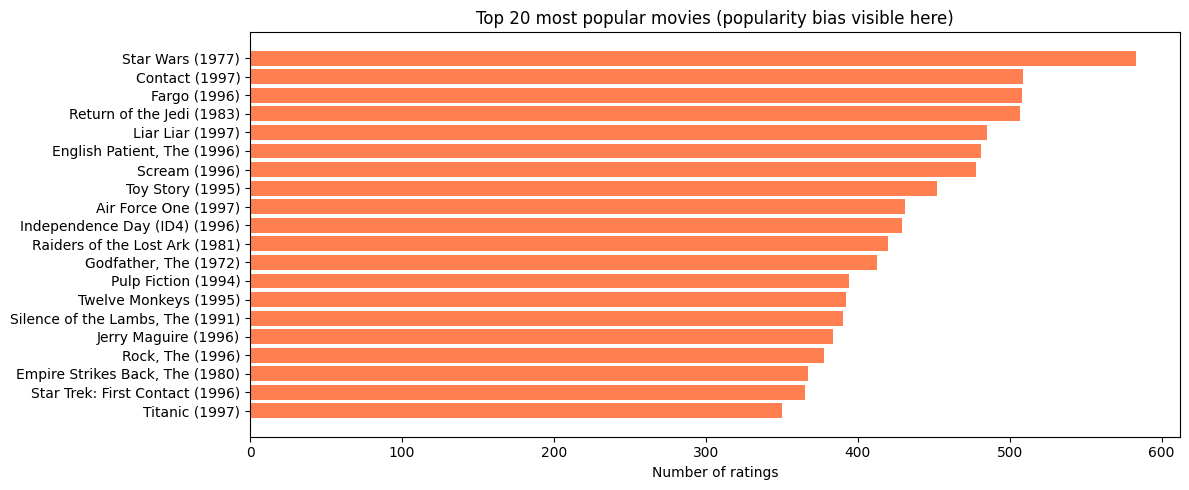

Total movies: 1682
Top 10 movies take up 4.9% of all ratings
Bottom 1672 movies share only 95.1% of ratings

This IS the popularity bias we are going to fix!


In [4]:
# Count how many ratings each movie has
movie_popularity = ratings.groupby('movie_id')['rating'].count().reset_index()
movie_popularity.columns = ['movie_id', 'rating_count']
movie_popularity = movie_popularity.merge(movies, on='movie_id')
movie_popularity = movie_popularity.sort_values('rating_count', ascending=False)

# Plot top 20 most rated movies
plt.figure(figsize=(12, 5))
top20 = movie_popularity.head(20)
plt.barh(top20['title'], top20['rating_count'], color='coral')
plt.xlabel('Number of ratings')
plt.title('Top 20 most popular movies (popularity bias visible here)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Show the imbalance
total_movies = len(movie_popularity)
top10_ratings = movie_popularity.head(10)['rating_count'].sum()
total_ratings = movie_popularity['rating_count'].sum()
bias_pct = round(top10_ratings / total_ratings * 100, 1)

print(f"Total movies: {total_movies}")
print(f"Top 10 movies take up {bias_pct}% of all ratings")
print(f"Bottom {total_movies-10} movies share only {100-bias_pct}% of ratings")
print(f"\nThis IS the popularity bias we are going to fix!")

In [5]:
# Get recommendations for all users using Stage 1 model
def get_recommendations(user_id, n=10):
    similar_users = user_similarity_df[user_id]\
                    .sort_values(ascending=False)[1:6].index
    watched = user_movie_matrix.loc[user_id][
              user_movie_matrix.loc[user_id] > 0].index
    similar_ratings = user_movie_matrix.loc[similar_users].mean()
    recommendations = similar_ratings.drop(watched)\
                      .sort_values(ascending=False).head(n)
    return recommendations.index.tolist()

# Sample 100 users and check their recommendations
sample_users = ratings['user_id'].unique()[:100]
all_recs = []
for user in sample_users:
    recs = get_recommendations(user)
    all_recs.extend(recs)

# Count how often each movie gets recommended
rec_counts = pd.Series(all_recs).value_counts().reset_index()
rec_counts.columns = ['movie_id', 'rec_count']
rec_counts = rec_counts.merge(movies, on='movie_id')

print("Top 10 most recommended movies (biased model):")
print(rec_counts.head(10)[['title', 'rec_count']].to_string(index=False))

top10_recs = rec_counts.head(10)['rec_count'].sum()
total_recs = rec_counts['rec_count'].sum()
print(f"\nTop 10 movies appear in {round(top10_recs/total_recs*100,1)}% of all recommendations")
print("This proves our model is biased towards popular movies!")

Top 10 most recommended movies (biased model):
                           title  rec_count
                Star Wars (1977)         15
           Godfather, The (1972)         14
      Princess Bride, The (1987)         12
       Return of the Jedi (1983)         12
  When Harry Met Sally... (1989)         10
Hunt for Red October, The (1990)          9
                Rock, The (1996)          9
               Braveheart (1995)          9
                  Titanic (1997)          9
                 Die Hard (1988)          9

Top 10 movies appear in 10.8% of all recommendations
This proves our model is biased towards popular movies!


In [6]:
# IPS Weighting — the causal fix
# Propensity = probability of a movie being rated = popularity

# Calculate propensity score for each movie
total_ratings = len(ratings)
propensity = ratings.groupby('movie_id')['rating'].count() / total_ratings
propensity = propensity.reset_index()
propensity.columns = ['movie_id', 'propensity']

# IPS weight = 1 / propensity (rare movies get higher weight)
propensity['ips_weight'] = 1 / propensity['propensity']

# Normalize weights
propensity['ips_weight'] = propensity['ips_weight'] / propensity['ips_weight'].max()

print("Propensity scores calculated!")
print("\nTop 5 popular movies (low IPS weight — penalized):")
print(propensity.merge(movies, on='movie_id')\
      .sort_values('propensity', ascending=False)\
      .head(5)[['title','propensity','ips_weight']].to_string(index=False))

print("\nTop 5 rare movies (high IPS weight — boosted):")
print(propensity.merge(movies, on='movie_id')\
      .sort_values('ips_weight', ascending=False)\
      .head(5)[['title','propensity','ips_weight']].to_string(index=False))

Propensity scores calculated!

Top 5 popular movies (low IPS weight — penalized):
                    title  propensity  ips_weight
         Star Wars (1977)     0.00583    0.001715
           Contact (1997)     0.00509    0.001965
             Fargo (1996)     0.00508    0.001969
Return of the Jedi (1983)     0.00507    0.001972
         Liar Liar (1997)     0.00485    0.002062

Top 5 rare movies (high IPS weight — boosted):
                                    title  propensity  ips_weight
                      New Age, The (1994)     0.00001         1.0
                              Ripe (1996)     0.00001         1.0
Scream of Stone (Schrei aus Stein) (1991)     0.00001         1.0
                 Brother's Kiss, A (1997)     0.00001         1.0
                    Next Step, The (1995)     0.00001         1.0


In [7]:
# Apply IPS weights to ratings
ratings_ips = ratings.merge(propensity[['movie_id','ips_weight']], on='movie_id')

# Weighted rating = actual rating * IPS weight
ratings_ips['weighted_rating'] = ratings_ips['rating'] * ratings_ips['ips_weight']

# Build weighted user-movie matrix
weighted_matrix = ratings_ips.pivot_table(
    index='user_id', columns='movie_id',
    values='weighted_rating').fillna(0)

# Retrain SVD on weighted matrix
svd_ips = TruncatedSVD(n_components=200, random_state=42)
matrix_svd_ips = svd_ips.fit_transform(weighted_matrix)

user_similarity_ips = pd.DataFrame(
    cosine_similarity(matrix_svd_ips),
    index=weighted_matrix.index,
    columns=weighted_matrix.index)

print("IPS-debiased model trained!")
print(f"Variance explained: {round(svd_ips.explained_variance_ratio_.sum()*100,1)}%")

IPS-debiased model trained!
Variance explained: 91.8%


In [8]:
def get_recommendations_ips(user_id, n=10):
    similar_users = user_similarity_ips[user_id]\
                    .sort_values(ascending=False)[1:6].index
    watched = weighted_matrix.loc[user_id][
              weighted_matrix.loc[user_id] > 0].index
    similar_ratings = weighted_matrix.loc[similar_users].mean()
    recommendations = similar_ratings.drop(watched)\
                      .sort_values(ascending=False).head(n)
    return recommendations.index.tolist()

# Sample same 100 users
all_recs_ips = []
for user in sample_users:
    recs = get_recommendations_ips(user)
    all_recs_ips.extend(recs)

rec_counts_ips = pd.Series(all_recs_ips).value_counts().reset_index()
rec_counts_ips.columns = ['movie_id', 'rec_count']
rec_counts_ips = rec_counts_ips.merge(movies, on='movie_id')

print("Top 10 most recommended movies (debiased model):")
print(rec_counts_ips.head(10)[['title','rec_count']].to_string(index=False))

top10_ips = rec_counts_ips.head(10)['rec_count'].sum()
total_ips = rec_counts_ips['rec_count'].sum()
print(f"\nTop 10 movies appear in {round(top10_ips/total_ips*100,1)}% of recommendations")

Top 10 most recommended movies (debiased model):
                              title  rec_count
                  Persuasion (1995)          8
              Color of Night (1994)          7
                       Naked (1993)          6
                   Walkabout (1971)          5
                  Houseguest (1994)          5
              Heaven & Earth (1993)          5
             Assignment, The (1997)          5
              Believers, The (1987)          5
                  Out to Sea (1997)          5
Transformers: The Movie, The (1986)          5

Top 10 movies appear in 5.6% of recommendations


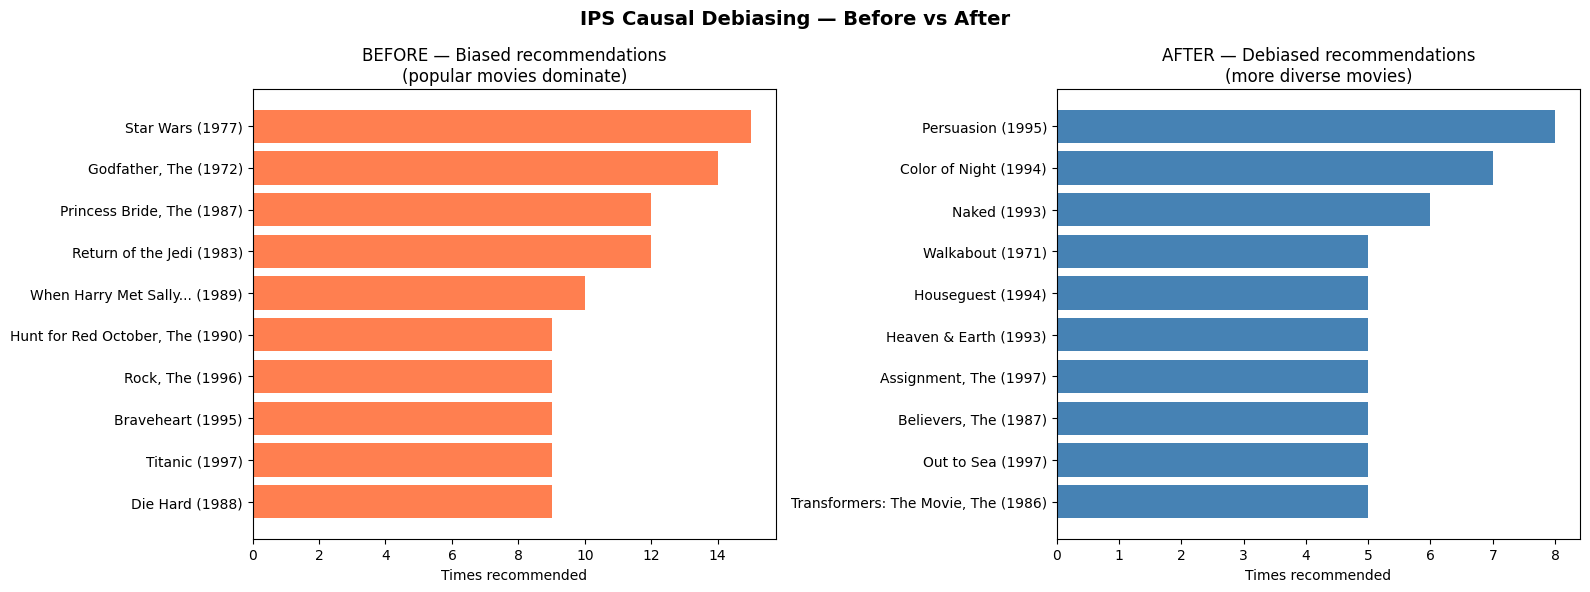

Bias before: 10.8%
Bias after:  5.6%
Bias reduction: 5.2% — this goes on your resume!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biased model
top10_biased = rec_counts.head(10)
axes[0].barh(top10_biased['title'], top10_biased['rec_count'], color='coral')
axes[0].set_title('BEFORE — Biased recommendations\n(popular movies dominate)')
axes[0].set_xlabel('Times recommended')
axes[0].invert_yaxis()

# Debiased model
top10_debiased = rec_counts_ips.head(10)
axes[1].barh(top10_debiased['title'], top10_debiased['rec_count'], color='steelblue')
axes[1].set_title('AFTER — Debiased recommendations\n(more diverse movies)')
axes[1].set_xlabel('Times recommended')
axes[1].invert_yaxis()

plt.suptitle('IPS Causal Debiasing — Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate bias reduction
bias_before = round(rec_counts.head(10)['rec_count'].sum() / rec_counts['rec_count'].sum() * 100, 1)
bias_after = round(rec_counts_ips.head(10)['rec_count'].sum() / rec_counts_ips['rec_count'].sum() * 100, 1)
reduction = round(bias_before - bias_after, 1)

print(f"Bias before: {bias_before}%")
print(f"Bias after:  {bias_after}%")
print(f"Bias reduction: {reduction}% — this goes on your resume!")